# [CSVLoader](https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.csv_loader.CSVLoader.html)
> CSV 파일을 읽어 각 행(row)을 하나의 Document로 변환

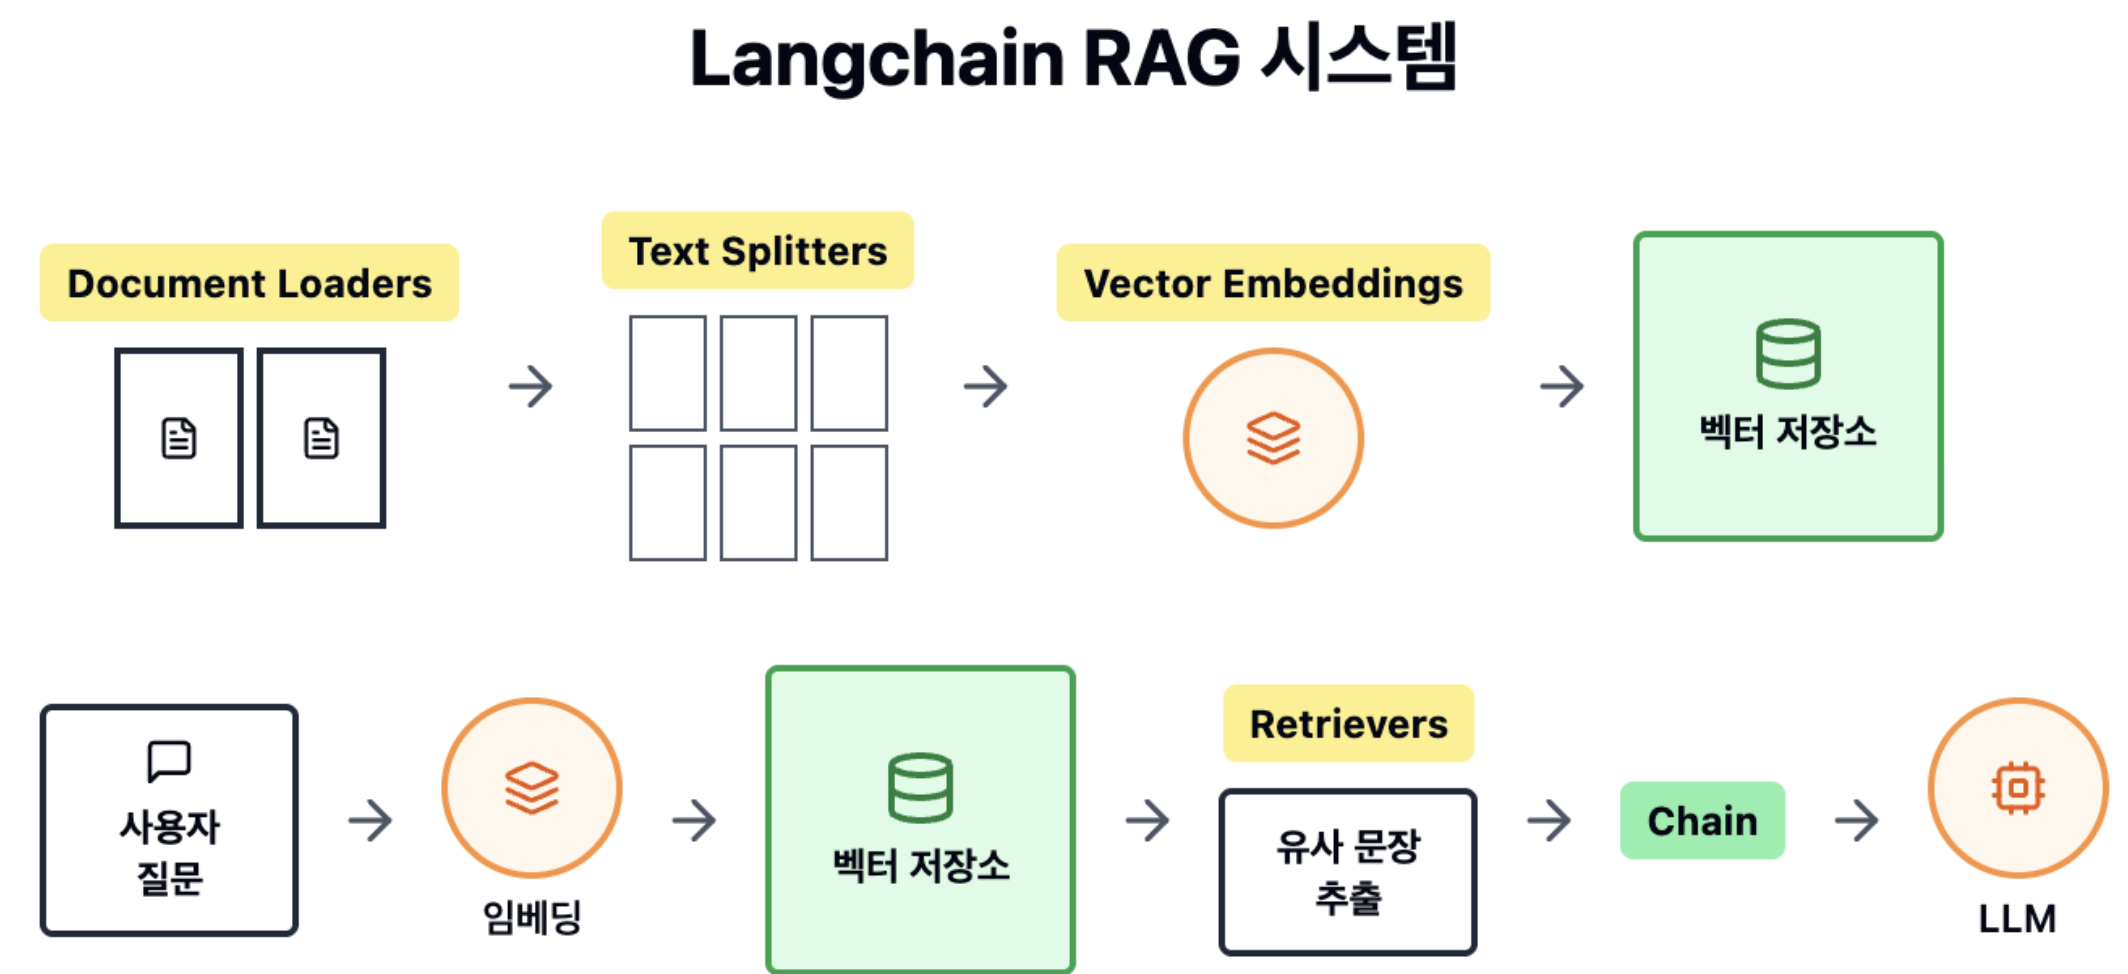

## CSV file

In [2]:
import pandas as pd

file_path = "./data/samsung_stock.csv"

df = pd.read_csv(file_path)

df.head()

,Date,Open,High,Low,Close,Volume,Change
0,2025-01-02,52700,53600,52300,53400,16630538,0.003759
1,2025-01-03,52800,55100,52800,54400,19318046,0.018727
2,2025-01-06,54400,56200,54300,55900,19034284,0.027574
3,2025-01-07,56800,57300,55400,55400,17030235,-0.008945
4,2025-01-08,54800,57500,54700,57300,26593553,0.034296


## 예제1

### Loader
| 인자                 | 설명                          |
| ------------------ | --------------------------- |
| `file_path`        | CSV 파일 경로                   |
| `source_column`    | `page_content`로 쓸 컬럼명       |
| `metadata_columns` | `metadata`에 포함할 컬럼 목록       |
| `encoding`         | 파일 인코딩                      |
| `csv_args`         | `csv.DictReader`에 전달할 추가 인자 |


In [3]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(file_path=file_path, encoding='utf-8',
    csv_args={
    'delimiter': ','
})

In [17]:
docs1 = loader.load() 

len(docs1)

129

### 확인 

In [18]:
for i, doc in enumerate(docs1[:2]):
    print("="*50)
    print(f"Document {i+1}:")
    print(f"   - 타입: {type(doc)}")
    print(f"   - page_content 타입: {type(doc.page_content)}")
    print(f"   - metadata 타입: {type(doc.metadata)}")
    print(f"   - metadata 내용: {doc.metadata}")
    print(f"   - 내용 길이: {len(doc.page_content)} 문자")
    print(f"   - 내용: \n{doc.page_content}")
    print()

Document 1:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'source': '53400', 'row': 0, 'Change': '0.003759398496240518', 'Date': '2025-01-02'}
   - 내용 길이: 64 문자
   - 내용: 
Open: 52700
High: 53600
Low: 52300
Close: 53400
Volume: 16630538

Document 2:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'source': '54400', 'row': 1, 'Change': '0.01872659176029967', 'Date': '2025-01-03'}
   - 내용 길이: 64 문자
   - 내용: 
Open: 52800
High: 55100
Low: 52800
Close: 54400
Volume: 19318046



## 예제2

### CustomCSVLoader

In [21]:
import pandas as pd
from langchain_core.documents import Document
from langchain_community.document_loaders.base import BaseLoader

class CustomCSVLoader(BaseLoader):
    def __init__(
        self,
        file_path: str,
        content_columns: list[str],
        metadata_columns: list[str],
        sep: str = ",",
        encoding: str = "utf-8",
        na_fill: str = ""
    ):
        """
        Custom CSV Loader using pandas.

        Args:
            file_path (str): CSV 파일 경로
            content_columns (list[str]): page_content로 사용할 컬럼들
            metadata_columns (list[str]): metadata로 포함할 컬럼들
            sep (str): 구분자 (기본값: ',')
            encoding (str): 인코딩 (기본값: 'utf-8')
            na_fill (str): 결측치 대체 문자열 (기본값: '')
        """
        self.file_path = file_path
        self.content_columns = content_columns
        self.metadata_columns = metadata_columns
        self.sep = sep
        self.encoding = encoding
        self.na_fill = na_fill

    def load(self) -> list[Document]:
        # pandas로 CSV 읽기
        df = pd.read_csv(self.file_path, sep=self.sep, encoding=self.encoding).fillna(self.na_fill)

        docs = []
        for _, row in df.iterrows():
            # page_content: 지정된 컬럼들을 합쳐서 문자열 생성
            content_parts = [f"{col}: {row[col]}" for col in self.content_columns if col in df.columns]
            page_content = " | ".join(content_parts)

            # metadata: 지정된 컬럼들만 선택
            metadata = {col: row[col] for col in self.metadata_columns if col in df.columns}
            metadata["source"] = self.file_path

            docs.append(Document(page_content=str(page_content), metadata=metadata))

        return docs


In [22]:
loader = CustomCSVLoader(
    file_path=file_path,
    content_columns=["Close", "description"],   # page_content로 합칠 컬럼
    metadata_columns=["Change", "Date"] # metadata로 넣을 컬럼
)

docs2 = loader.load()

### 확인

In [23]:
for i, doc in enumerate(docs2[:2]):
    print("="*50)
    print(f"Document {i+1}:")
    print(f"   - 타입: {type(doc)}")
    print(f"   - page_content 타입: {type(doc.page_content)}")
    print(f"   - metadata 타입: {type(doc.metadata)}")
    print(f"   - metadata 내용: {doc.metadata}")
    print(f"   - 내용 길이: {len(doc.page_content)} 문자")
    print(f"   - 내용: \n{doc.page_content}")
    print()

Document 1:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'Change': 0.0037593984962405, 'Date': '2025-01-02', 'source': './data/samsung_stock.csv'}
   - 내용 길이: 12 문자
   - 내용: 
Close: 53400

Document 2:
   - 타입: <class 'langchain_core.documents.base.Document'>
   - page_content 타입: <class 'str'>
   - metadata 타입: <class 'dict'>
   - metadata 내용: {'Change': 0.0187265917602996, 'Date': '2025-01-03', 'source': './data/samsung_stock.csv'}
   - 내용 길이: 12 문자
   - 내용: 
Close: 54400

